# 04 - Intermediate Fusion / Feature-Level Fusion (CNN + FCNN)

**Tujuan:** Melatih model Intermediate Fusion yang menggabungkan fitur penampilan (CNN) dan fitur geometrik (FCNN) di level fitur (feature-level) untuk pengenalan emosi.

**Catatan terminologi:** Arsitektur ini disebut **Intermediate Fusion** (Boulahia et al., 2021) karena fusi dilakukan di level representasi fitur yang diekstrak masing-masing subnetwork, bukan di level input (early fusion) maupun di level keputusan (late fusion). Istilah lain yang setara: *feature-level fusion* atau *middle fusion*. Ini **berbeda dengan hybrid fusion** yang menggabungkan dua atau lebih strategi fusi sekaligus.

**Menjawab RQ3:** *Bagaimana performa model multimodal Intermediate Fusion (CNN + FCNN) dalam pengenalan emosi mahasiswa pada konteks pembelajaran pemrograman menggunakan gabungan fitur penampilan dan fitur geometrik?*

**Arsitektur:**
- Image stream (CNN): 3 Conv blocks → 256-dim feature vector
- Landmark stream (FCNN): 4 Dense layers → 128-dim feature vector
- Concatenate (384-dim) → Dense(512→256) → 7 classes

**3 Skenario Imbalance:**
- B1: Tanpa penanganan (baseline)
- B2: Dengan class weights (Cui et al., 2019)
- B3: Dengan class weights + augmentasi

## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import IntermediateFusion
from training.utils import (
    EmotionMultimodalDataset, get_class_weights,
    train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "intermediate_fusion"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 16
EPOCHS = 80
LR = 0.0001
PATIENCE = 25
NUM_CLASSES = 7

EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/intermediate_fusion


## 2. Load Data

In [3]:
from torch.utils.data import DataLoader
from collections import Counter

def load_dataloaders(dataset_dir, batch_size=16):
    """Load train/val/test dataloaders for multimodal (images + landmarks)."""
    train_ds = EmotionMultimodalDataset(
        dataset_dir / "X_train_images.npy",
        dataset_dir / "X_train_landmarks.npy",
        dataset_dir / "y_train.npy"
    )
    val_ds = EmotionMultimodalDataset(
        dataset_dir / "X_val_images.npy",
        dataset_dir / "X_val_landmarks.npy",
        dataset_dir / "y_val.npy"
    )
    test_ds = EmotionMultimodalDataset(
        dataset_dir / "X_test_images.npy",
        dataset_dir / "X_test_landmarks.npy",
        dataset_dir / "y_test.npy"
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Print info
    y_train = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y_train.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Train distribution:")
    for i, emo in enumerate(EMOTIONS):
        print(f"  {emo:>10s}: {counts.get(i, 0)}")

    return train_loader, val_loader, test_loader

# Load original dataset
train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 7064 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
       angry: 48
     fearful: 8
   disgusted: 19
   surprised: 70


## 3. Skenario B1: Baseline (Tanpa Class Weights)

In [4]:
# B1: Baseline - no class weights
model_b1 = IntermediateFusion(num_classes=NUM_CLASSES, landmark_dim=136).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print(f"Model parameters: {sum(p.numel() for p in model_b1.parameters()):,}")
print("Training B1 (baseline)...")
history_b1, best_epoch_b1 = train_model(
    model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_b1_baseline.pth")
)

Model parameters: 52,466,471
Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9737     0.7411     0.8719    0.9284   0.1376   0.000100  (46.4s)


     2      0.7083     0.8024     0.7153    0.9284   0.1376   0.000100  (46.1s)


     3      0.6672     0.8039     0.5940    0.9284   0.1376   0.000100  (45.9s)


     4      0.6346     0.8056     0.6553    0.9216   0.1526   0.000100  (45.9s)


...

    33      0.2303     0.9197     0.4887    0.8722   0.1895   0.000025  (45.8s)


    34      0.2330     0.9197     0.6002    0.7896   0.1726   0.000025  (45.8s)


    35      0.2190     0.9230     0.6048    0.8007   0.1746   0.000025  (45.7s)


    36      0.2193     0.9231     0.5869    0.8015   0.1720   0.000025  (45.7s)


    37      0.2164     0.9226     0.5100    0.8458   0.1803   0.000025  (45.7s)

Early stopping at epoch 37. Best epoch: 12 (val_f1=0.2622)

Best: epoch 12, val_acc=0.9387, val_f1=0.2622
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/intermediate_fusion/intermediate_b1_baseline.pth


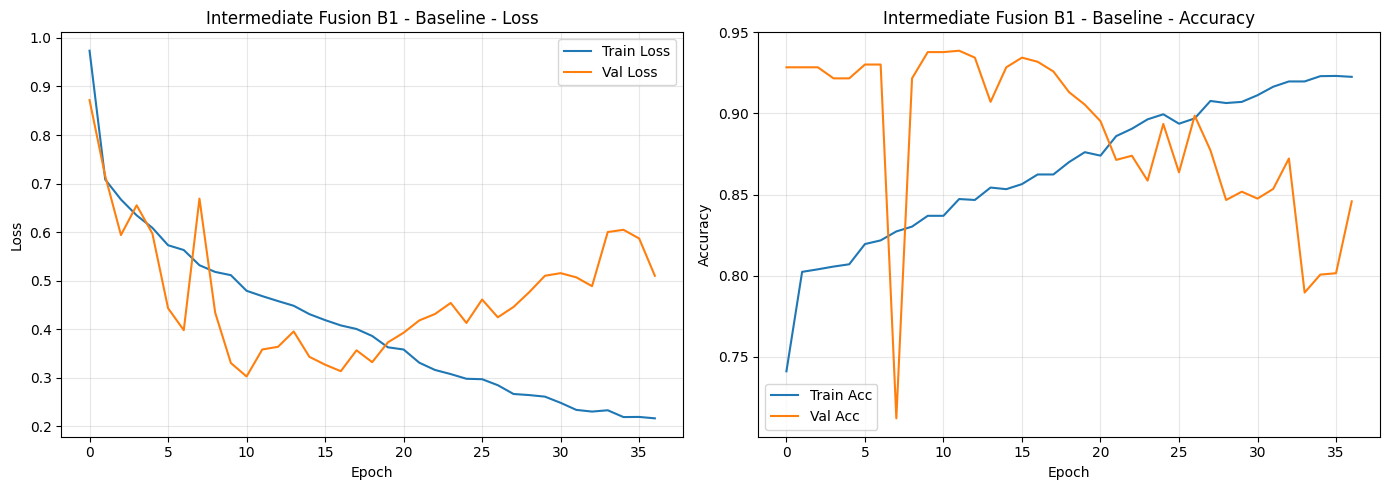

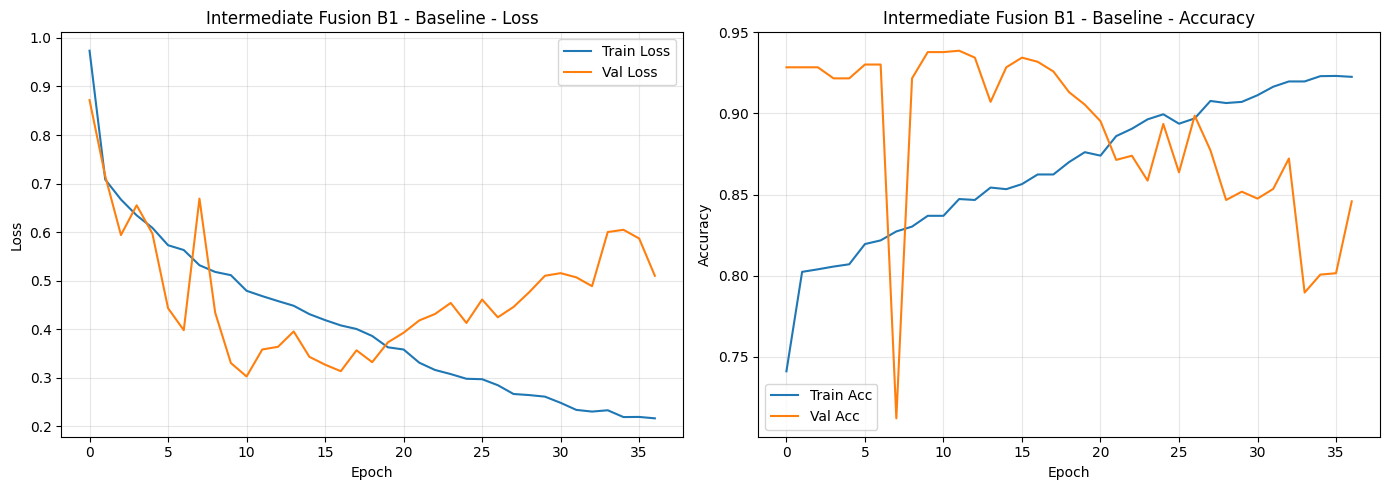

In [5]:
plot_training_history(history_b1, "Intermediate Fusion B1 - Baseline")

EVALUASI B1 - BASELINE


Test Loss: 0.7159
Test Accuracy: 0.6329
Test Macro F1: 0.1115
Test Weighted F1: 0.7443

Classification Report:
              precision    recall  f1-score   support

     neutral       0.94      0.66      0.78      1588
       happy       0.00      0.10      0.00        10
         sad       0.00      0.00      0.00        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.63      1656
   macro avg       0.14      0.11      0.11      1656
weighted avg       0.90      0.63      0.74      1656



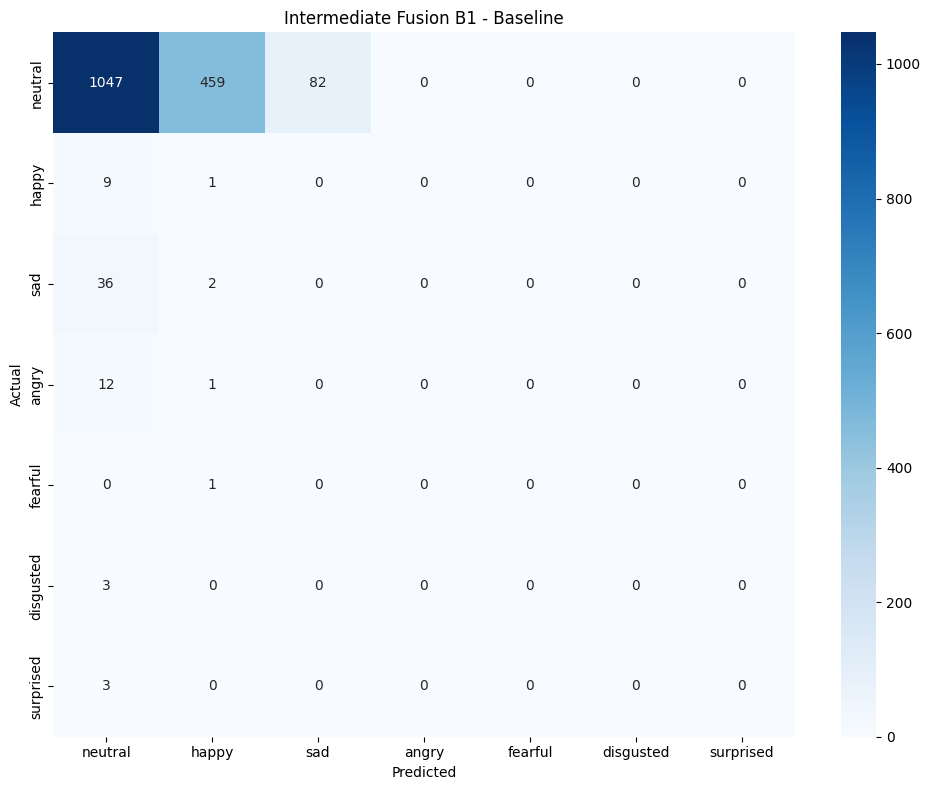

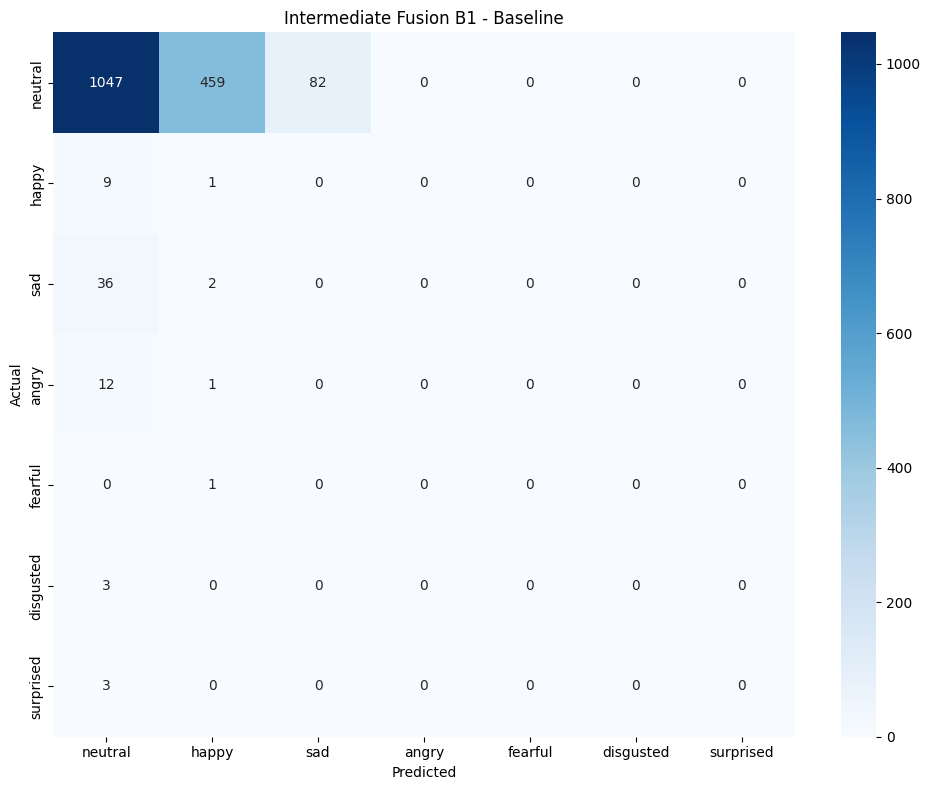

In [6]:
# Evaluate B1 on test set
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "fusion")
plot_confusion_matrix(results_b1["confusion_matrix"], "Intermediate Fusion B1 - Baseline")

## 4. Skenario B2: Dengan Class Weights

In [7]:
# B2: With class weights (Cui et al., 2019)
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")

model_b2 = IntermediateFusion(num_classes=NUM_CLASSES, landmark_dim=136).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B2 (class weights)...")
history_b2, best_epoch_b2 = train_model(
    model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_b2_weighted.pth")
)

Class weights: tensor([  1.0000,   1.8865,   2.5717,  21.2542, 125.0103,  52.9257,  14.7340],
       device='cuda:0')



Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.6084     0.6134     1.4877    0.9276   0.1375   0.000100  (45.6s)


     2      1.3793     0.7836     1.4643    0.7385   0.1237   0.000100  (45.6s)


     3      1.3264     0.7823     1.3913    0.7428   0.1229   0.000100  (45.6s)


...

    38      0.3875     0.8795     1.0281    0.8186   0.1695   0.000025  (45.7s)


    39      0.4018     0.8781     1.0342    0.7862   0.1677   0.000025  (45.6s)


    40      0.3819     0.8758     1.0340    0.7828   0.1654   0.000025  (45.6s)


    41      0.3880     0.8770     1.0523    0.7717   0.1672   0.000025  (45.6s)


    42      0.3806     0.8815     1.0612    0.7913   0.1711   0.000025  (45.6s)

Early stopping at epoch 42. Best epoch: 17 (val_f1=0.2260)

Best: epoch 17, val_acc=0.9293, val_f1=0.2260
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/intermediate_fusion/intermediate_b2_weighted.pth


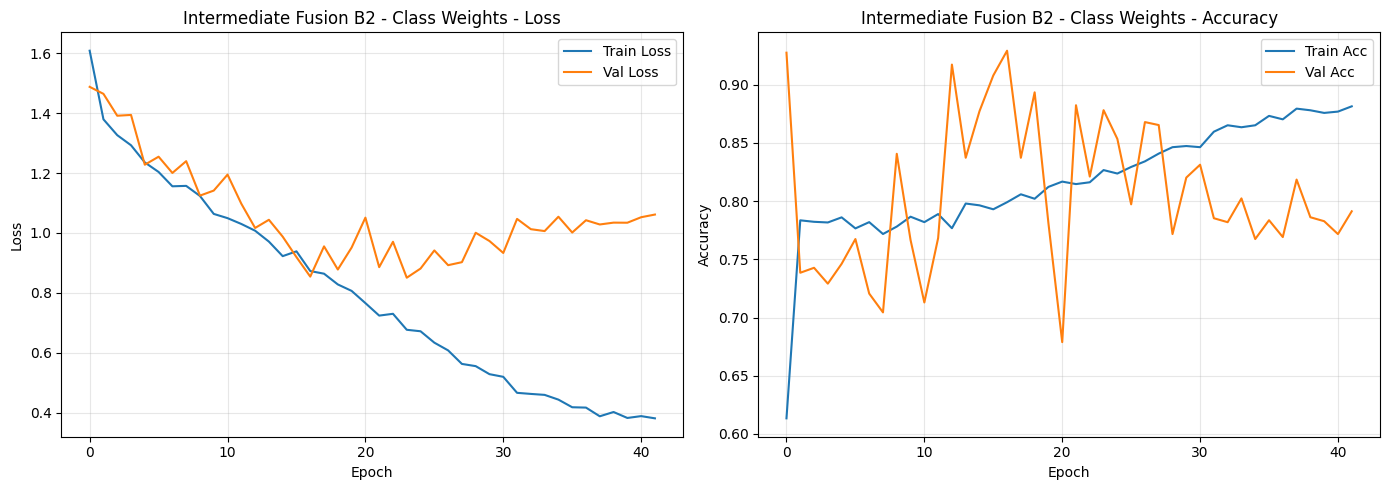

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 1.0112
Test Accuracy: 0.8448
Test Macro F1: 0.1399
Test Weighted F1: 0.8809

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.88      0.92      1588
       happy       0.00      0.00      0.00        10
         sad       0.00      0.00      0.00        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.03      0.33      0.06         3

    accuracy                           0.84      1656
   macro avg       0.14      0.17      0.14      1656
weighted avg       0.92      0.84      0.88      1656



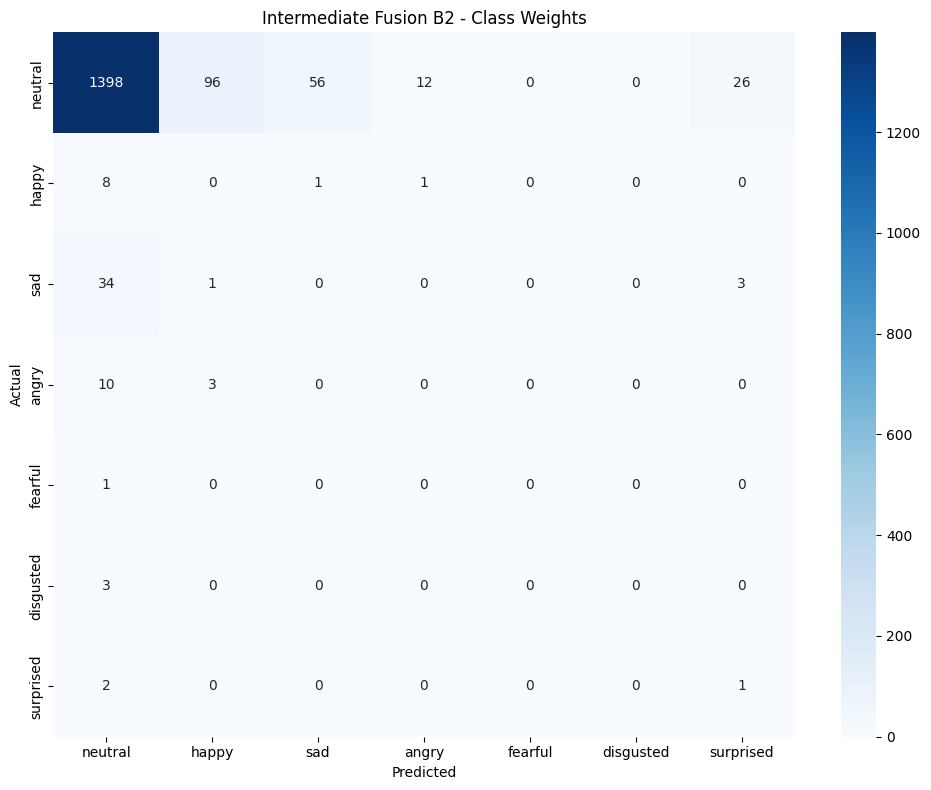

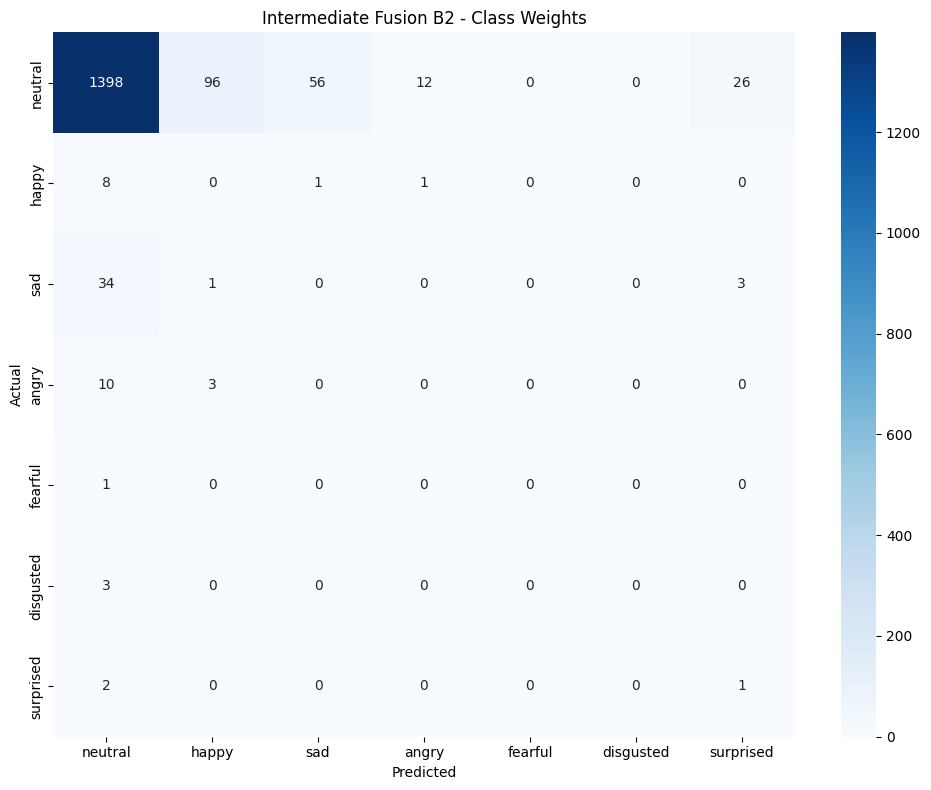

In [8]:
plot_training_history(history_b2, "Intermediate Fusion B2 - Class Weights")

print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "fusion")
plot_confusion_matrix(results_b2["confusion_matrix"], "Intermediate Fusion B2 - Class Weights")

## 5. Skenario B3: Class Weights + Augmentasi

In [9]:
# B3: Class weights + augmented data
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")

model_b3 = IntermediateFusion(num_classes=NUM_CLASSES, landmark_dim=136).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B3 (class weights + augmentation)...")
history_b3, best_epoch_b3 = train_model(
    model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_b3_augmented.pth")
)

Train: 7519 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150
Augmented class weights: tensor([1.0000, 1.8865, 2.5717, 7.1514, 7.1514, 7.1514, 7.1514],
       device='cuda:0')



Training B3 (class weights + augmentation)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.7183     0.5743     1.2126    0.9233   0.1372   0.000100  (49.6s)


     2      1.4811     0.7385     1.0725    0.9250   0.1373   0.000100  (49.7s)


     3      1.3726     0.7391     1.0656    0.9216   0.1370   0.000100  (49.8s)


...

    32      0.2906     0.8911     0.8654    0.9020   0.1929   0.000025  (49.6s)


    33      0.2942     0.8937     0.8830    0.8995   0.1944   0.000025  (49.8s)


    34      0.2796     0.8961     0.8947    0.9097   0.2015   0.000025  (49.8s)


    35      0.2834     0.9001     0.8692    0.8935   0.1996   0.000025  (49.8s)


    36      0.2644     0.9007     0.9268    0.8969   0.1891   0.000025  (49.8s)

Early stopping at epoch 36. Best epoch: 11 (val_f1=0.2159)

Best: epoch 11, val_acc=0.9302, val_f1=0.2159
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/intermediate_fusion/intermediate_b3_augmented.pth


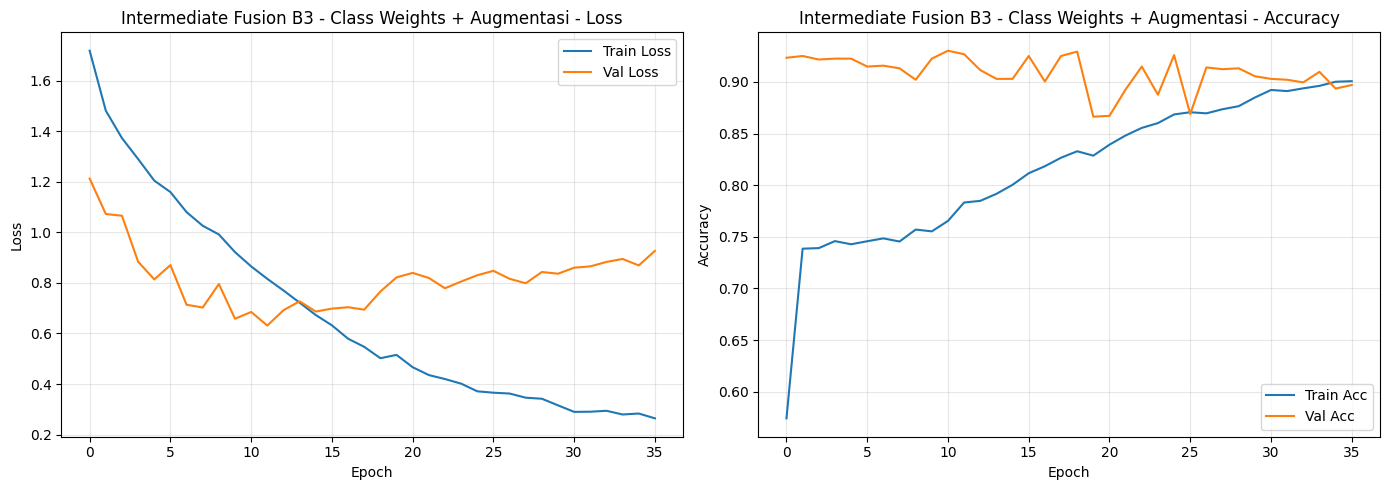

EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI


Test Loss: 0.7902
Test Accuracy: 0.8158
Test Macro F1: 0.1336
Test Weighted F1: 0.8665

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.85      0.90      1588
       happy       0.00      0.00      0.00        10
         sad       0.02      0.11      0.03        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.82      1656
   macro avg       0.14      0.14      0.13      1656
weighted avg       0.93      0.82      0.87      1656



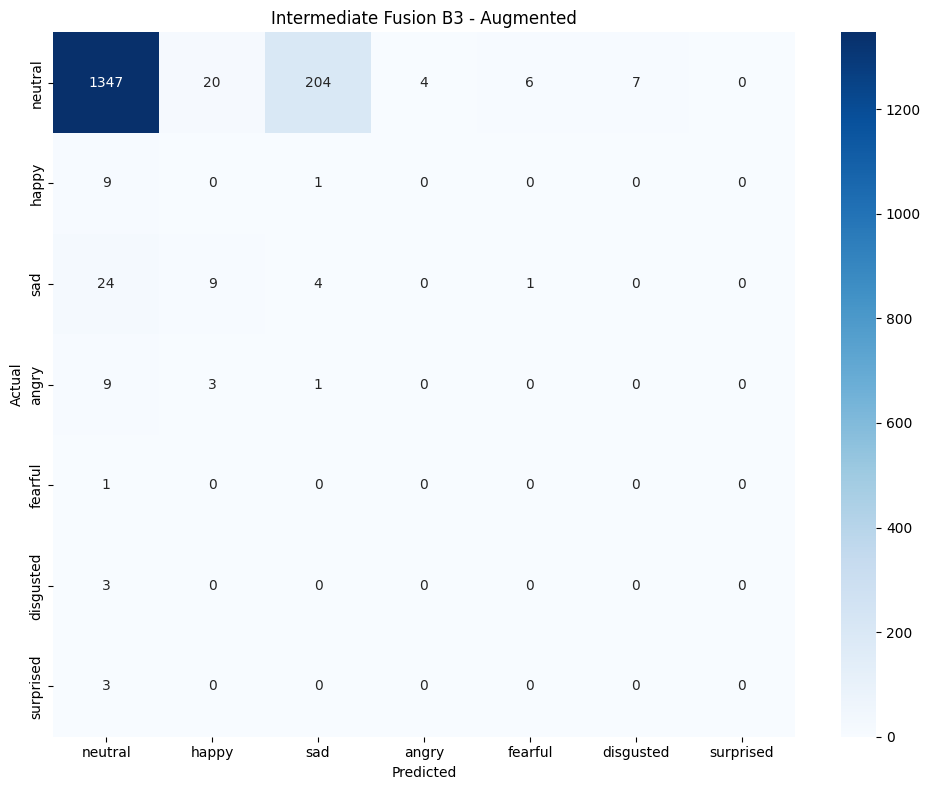

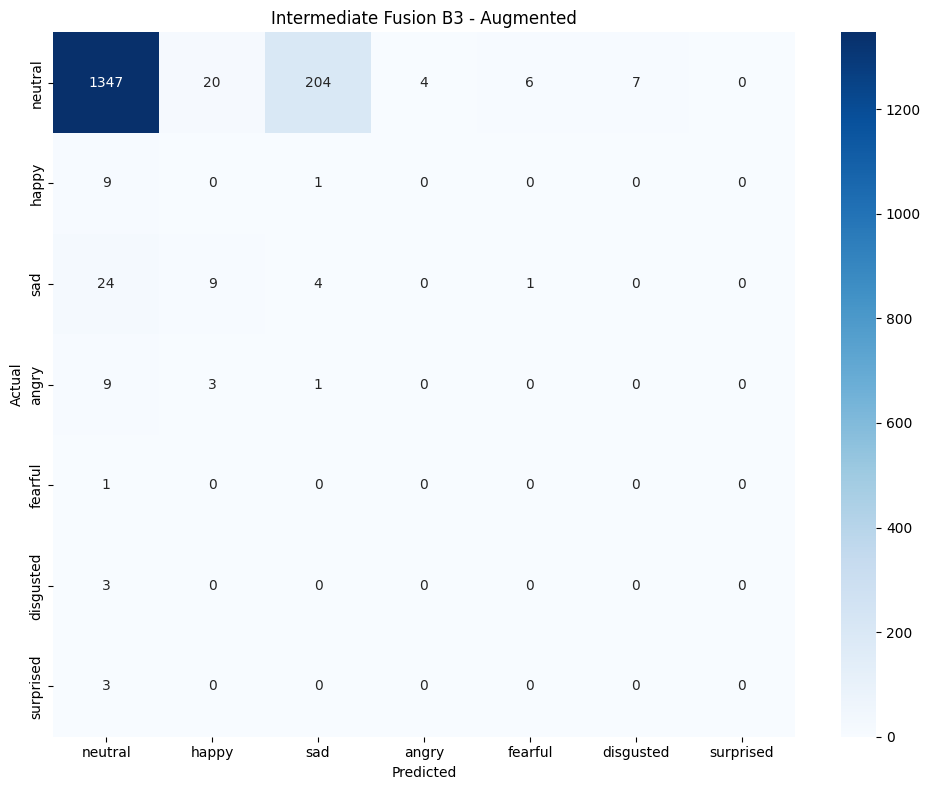

In [10]:
plot_training_history(history_b3, "Intermediate Fusion B3 - Class Weights + Augmentasi")

print("=" * 60)
print("EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "fusion")
plot_confusion_matrix(results_b3["confusion_matrix"], "Intermediate Fusion B3 - Augmented")

## 6. Perbandingan 3 Skenario

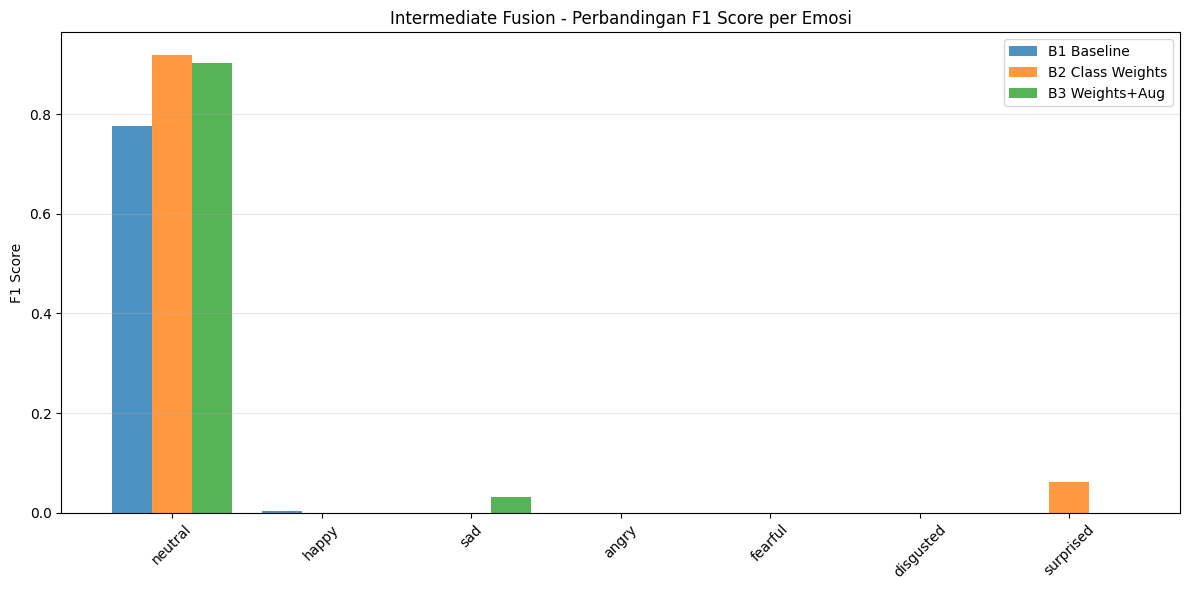

RINGKASAN INTERMEDIATE FUSION - 3 SKENARIO
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.6329     0.1115       0.7443
B2 Class Weights              0.8448     0.1399       0.8809
B3 Weights+Aug                0.8158     0.1336       0.8665


In [11]:
# Perbandingan per-class F1 score
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "Intermediate Fusion - Perbandingan F1 Score per Emosi")

# Summary table
print("=" * 70)
print("RINGKASAN INTERMEDIATE FUSION - 3 SKENARIO")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

## 7. Simpan Hasil

In [12]:
# Save results
fusion_results = {}
for name, r in all_results.items():
    fusion_results[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "intermediate_fusion_results.json", "w") as f:
    json.dump(fusion_results, f, indent=2)
print(f"Results saved to {OUTPUT_DIR / 'intermediate_fusion_results.json'}")

Results saved to /home/bs000716/MOTHER-TANK/TRAIN/models/intermediate_fusion/intermediate_fusion_results.json
